# <span style="color:blue">Workshop 4a: Rule-Based GP in DEAP</span>

# <span style="color:Blue">Exercise: Santa Fe Ant Trail Problem</span>

# <span style="color:#0073e6">Context</span>

The artificial ant problem (or Santa Fe Ant Problem) is a well-studied problem with a simple fitness function. The problem is to devise an agent that can successfully navigate an artificial ant along a trail on a square grid to collect as much food as possible within a maximum number of moves (here 600). You can see a visualization of the problem here:
https://www.youtube.com/watch?v=BKF7pGw8qbY

# <span style="color:#0073e6">Map Setup</span>

Make sure that you have the file santafe_trail.txt in the same folder as the notebook. This text file includes the map for the ants to solve. Open the map in a text editor. You can see that empty cells are represented with periods and food is represented with a hash. There is only one map to work with here, but you can create your own varitions of this in your text editor.

# <span style="color:#0073e6">The Ant Class</span>

In the code, an ant will follow the instructions provided to it from an individual (an evolved decision tree) evolved by GP. So there is a single ant agent that is used to evaluate your individuals, but a population of individuals that use the ant for evaluation.  A basic way to evaluate fitness is simply looking at how much a particular ant has eaten (ant.eaten), which is implemented here.

An ant can navigate based on three operations:
- Move_Forward	- Move the ant forward one square
- Turn_Right		- Turn the ant to the right 90 degrees
- Turn_Left		- Turn the ant to the left 90 degrees.

These three commands therefore part of the terminal set in a GP. Each of these operations is assumed to take one time unit to execute.

The sensing function if_food_ahead looks into the square the ant is currently facing and then executes one of its two arguments depending upon whether that square contains food or is empty. Two other functions, Prog2 and Prog3, are provided. These take two and three arguments respectively which are executed in sequence. These three functions are therefore also part of the primitive set.

# <span style="color:Blue">Exercise 1: Implement the GP</span>

1. Go through the code below and try to understand what it the ant is doing and how the problem works.
2. Code the genetic programming algorithm to find a solution (as in previous examples).
3. The best solution in terms of number of food items eaten is 89 for this problem. Can you improve the performance of your algorithm? Be sure to also output your final best solution as tree for examination.

In [1]:
!pip install deap

In [2]:
!apt install libgraphviz-dev
!pip install pygraphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libgraphviz-dev is already the newest version (2.42.2-6).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


# <span style="color:#0073e6">Ant Code</span>

In [3]:
import copy
import random
import numpy
import pygraphviz as pgv
from functools import partial

from deap import base
from deap import creator
from deap import tools
from deap import gp

In [4]:
class AntSimulator(object):
    direction = ["north","east","south","west"]
    dir_row = [1, 0, -1, 0]
    dir_col = [0, 1, 0, -1]

    def __init__(self, max_moves):
        self.max_moves = max_moves
        self.moves = 0
        self.eaten = 0
        self.routine = None

    def _reset(self):
        self.row = self.row_start
        self.col = self.col_start
        self.dir = 1
        self.moves = 0
        self.eaten = 0
        self.matrix_exc = copy.deepcopy(self.matrix)

    @property
    def position(self):
        return (self.row, self.col, self.direction[self.dir])

    def turn_left(self):
        if self.moves < self.max_moves:
            self.moves += 1
            self.dir = (self.dir - 1) % 4

    def turn_right(self):
        if self.moves < self.max_moves:
            self.moves += 1
            self.dir = (self.dir + 1) % 4

    def move_forward(self):
        if self.moves < self.max_moves:
            self.moves += 1
            self.row = (self.row + self.dir_row[self.dir]) % self.matrix_row
            self.col = (self.col + self.dir_col[self.dir]) % self.matrix_col
            if self.matrix_exc[self.row][self.col] == "food":
                self.eaten += 1
            self.matrix_exc[self.row][self.col] = "passed"

    def sense_food(self):
        ahead_row = (self.row + self.dir_row[self.dir]) % self.matrix_row
        ahead_col = (self.col + self.dir_col[self.dir]) % self.matrix_col
        return self.matrix_exc[ahead_row][ahead_col] == "food"

    def if_food_ahead(self, out1, out2):
        return partial(if_then_else, self.sense_food, out1, out2)

    def run(self,routine):
        self._reset()
        while self.moves < self.max_moves:
            routine()

    def parse_matrix(self, matrix):
        self.matrix = list()
        for i, line in enumerate(matrix):
            self.matrix.append(list())
            for j, col in enumerate(line):
                if col == "#":
                    self.matrix[-1].append("food")
                elif col == ".":
                    self.matrix[-1].append("empty")
                elif col == "S":
                    self.matrix[-1].append("empty")
                    self.row_start = self.row = i
                    self.col_start = self.col = j
                    self.dir = 1
        self.matrix_row = len(self.matrix)
        self.matrix_col = len(self.matrix[0])
        self.matrix_exc = copy.deepcopy(self.matrix)

In [5]:
ant = AntSimulator(600)

with  open("santafe_trail.txt") as trail_file:
    ant.parse_matrix(trail_file)

# <span style="color:Blue">You need to decide on your GP below</span>

We now need to define our primitive set. I see a lot of mistakes when defining the "Main" function here. That is because the ant uses information from the environment, and students add these as arguments. However, if you look at the code, the ant object directly accesses the environment, and it is not passed to the evolved function as an argment. As such, we have zero arguments here. However, you could modify the code to pass the arguments, if you liked, and then would need to modify it here.

Don't forget that here you might need to define and register progs (allowing multiple functions to connect together) and your own functions (e.g. if_then_else). No cheating and registering pre-programmed behaviour, though!

Your terminals are the ant behaviour. So for example:
> pset.addTerminal(ant.move_forward)

## <span style="color:#0073e6">Add your primitives and terminals here</span>

In [6]:
pset = gp.PrimitiveSet("MAIN", 0)

In the primitive set below we have added as terminals the ant functions to move_forward, turn_left and turn_right. These are essential for the ant to move around.

We have added prog2 and prog3 (based on the definition of progn(*args)) which will allow the tree to contain sequences of operations.

We have also added a definition of if_then_else(condition, out1, out2), which will select function out1() or out2() based on the value of condition(). This is used by the definition of if_food_ahead() in the Ant code above.

In [7]:
def progn(*args):
    for arg in args:
        arg()

def prog2(out1, out2):
    return partial(progn,out1,out2)

def prog3(out1, out2, out3):
    return partial(progn,out1,out2,out3)

def if_then_else(condition, out1, out2):
    out1() if condition() else out2()

pset.addPrimitive(ant.if_food_ahead, 2)
pset.addPrimitive(prog2, 2)
pset.addPrimitive(prog3, 3)
pset.addTerminal(ant.move_forward)
pset.addTerminal(ant.turn_left)
pset.addTerminal(ant.turn_right)

## <span style="color:#0073e6">Register your individuals, fitness and operators here</span>

In [8]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMax)

In [9]:
toolbox = base.Toolbox()
toolbox.register("expr_init", gp.genFull, pset=pset, min_=1, max_=2)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr_init)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

The code below registers one of two different selection functions.

The first is the standard tournament selection. This does not take into account the size of the tree, so we may evolved very large, bloated trees.

The second is a double tournament. The first tournament is based on selecting for fitness, the second tournament selects with a probability based on the relative size of trees.

In [10]:
#toolbox.register("select", tools.selTournament, tournsize=7)
toolbox.register("select", tools.selDoubleTournament, fitness_size = 7, parsimony_size = 1.4, fitness_first = True, fit_attr='fitness' )
toolbox.register("mate", gp.cxOnePoint)
toolbox.register("expr_mut", gp.genFull, min_=0, max_=3)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr_mut, pset=pset)
# Try parsimony_size = 1.8

## <span style="color:#0073e6">Evaluation functions</span>

We have two versions of the evaluation function here.

The first one compiles the individual into a runnable function, runs the game, and then returns the amount of food eaten.

The second one adds a penalty to the fitness, to try to control bloat in the tree. The penalty is calculated as the tree height squared, and is subtracted from the amount of food eaten. This penalises the larger trees.

In [11]:
def evalArtificialAnt(individual):
    routine = gp.compile(individual, pset)
    ant.run(routine)
    return ant.eaten,

#def evalArtificialAntBloatPenalty(individual):
#    routine = gp.compile(individual, pset)
#    ant.run(routine)
#    return ant.eaten - (individual.height)**2.0,

toolbox.register("evaluate", evalArtificialAnt)

## <span style="color:#0073e6">Register some stats</span>

In [12]:
stats_fit = tools.Statistics(lambda ind: ind.fitness.values)
stats_size = tools.Statistics(len)
stats = tools.MultiStatistics(fitness=stats_fit, size=stats_size)
stats.register("avg", numpy.mean)
stats.register("std", numpy.std)
stats.register("min", numpy.min)
stats.register("max", numpy.max)

## <span style="color:#0073e6">Main body</span>

In [13]:
logbook = tools.Logbook()
pop = toolbox.population(n=50) #

NGEN, CXPB, MUTPB = 50, 0.2, 0.2

fitnesses = list(map(toolbox.evaluate, pop))
for ind, fit in zip(pop, fitnesses):
    ind.fitness.values = fit

for g in range(NGEN):
    print("-- Generation %i --" % g)

    offspring = toolbox.select(pop, len(pop))
    offspring = list(map(toolbox.clone, offspring))

    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < CXPB:
            toolbox.mate(child1, child2)
            del child1.fitness.values
            del child2.fitness.values

    for mutant in offspring:
        if random.random() < MUTPB:
            toolbox.mutate(mutant)
            del mutant.fitness.values

    invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses = map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    Neval = len(invalid_ind)

    pop[:] = offspring

    record = stats.compile(pop)

    logbook.record(gen=g, evals=Neval, **record)

    #print("-- End of evolution --")

-- Generation 0 --
-- Generation 1 --
-- Generation 2 --
-- Generation 3 --
-- Generation 4 --
-- Generation 5 --
-- Generation 6 --
-- Generation 7 --
-- Generation 8 --
-- Generation 9 --
-- Generation 10 --
-- Generation 11 --
-- Generation 12 --
-- Generation 13 --
-- Generation 14 --
-- Generation 15 --
-- Generation 16 --
-- Generation 17 --
-- Generation 18 --
-- Generation 19 --
-- Generation 20 --
-- Generation 21 --
-- Generation 22 --
-- Generation 23 --
-- Generation 24 --
-- Generation 25 --
-- Generation 26 --
-- Generation 27 --
-- Generation 28 --
-- Generation 29 --
-- Generation 30 --
-- Generation 31 --
-- Generation 32 --
-- Generation 33 --
-- Generation 34 --
-- Generation 35 --
-- Generation 36 --
-- Generation 37 --
-- Generation 38 --
-- Generation 39 --
-- Generation 40 --
-- Generation 41 --
-- Generation 42 --
-- Generation 43 --
-- Generation 44 --
-- Generation 45 --
-- Generation 46 --
-- Generation 47 --
-- Generation 48 --
-- Generation 49 --


## <span style="color:#0073e6">Basic plots</span>

Text(0, 0.5, 'Fitness')

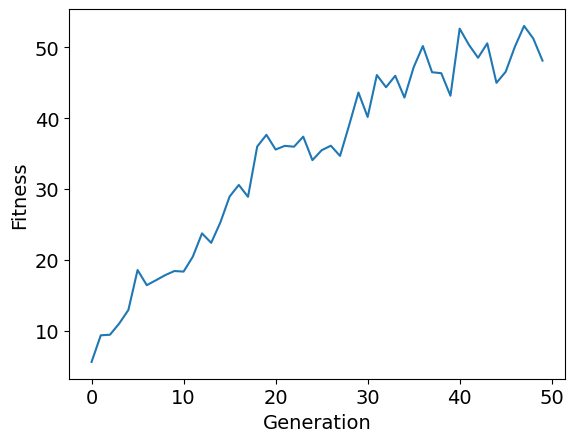

In [14]:
import matplotlib.pyplot as plt
%matplotlib inline

gen = logbook.chapters['fitness'].select("gen")
_min = logbook.chapters['fitness'].select("min")
_max = logbook.chapters['fitness'].select("max")
avgs = logbook.chapters['fitness'].select("avg")
stds = logbook.chapters['fitness'].select("std")

plt.rc('axes', labelsize=14)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('legend', fontsize=14)

fig, ax1 = plt.subplots()
line1 = ax1.plot(gen, avgs)
ax1.set_xlabel("Generation")
ax1.set_ylabel("Fitness")

#line2 = ax1.plot(gen, _min)
#line3 = ax1.plot(gen, _max)

For clarity here, I'm only showing the increase in the average fitness.

# <span style="color:#0073e6">Examine the best individual</span>

This prints out the expression form of the program syntax tree that has been involved.

In [15]:
indv = tools.selBest(pop, 1)[0]
print(indv)

prog2(prog3(move_forward, prog2(prog2(if_food_ahead(prog3(move_forward, move_forward, if_food_ahead(prog2(move_forward, move_forward), move_forward)), prog2(move_forward, turn_left)), if_food_ahead(prog2(move_forward, move_forward), move_forward)), move_forward), move_forward), if_food_ahead(move_forward, turn_right))


In [16]:
toolbox.evaluate(indv)

(58,)

We now turn the expression form into a printable tree form using pygraphviz.

In [17]:
nodes, edges, labels = gp.graph(indv)   #extract nodes, edges and labels from the expression form

tree = pgv.AGraph()                     #create an empty tree
tree.add_nodes_from(nodes)              #add the nodes and edges to the tree
tree.add_edges_from(edges)
tree.layout(prog="dot")                 #use the program "dot" to deicde the layout of the tree

for i in nodes:                         #iteratively add the labels to the nodes
    n = tree.get_node(i)
    n.attr["label"] = labels[i]

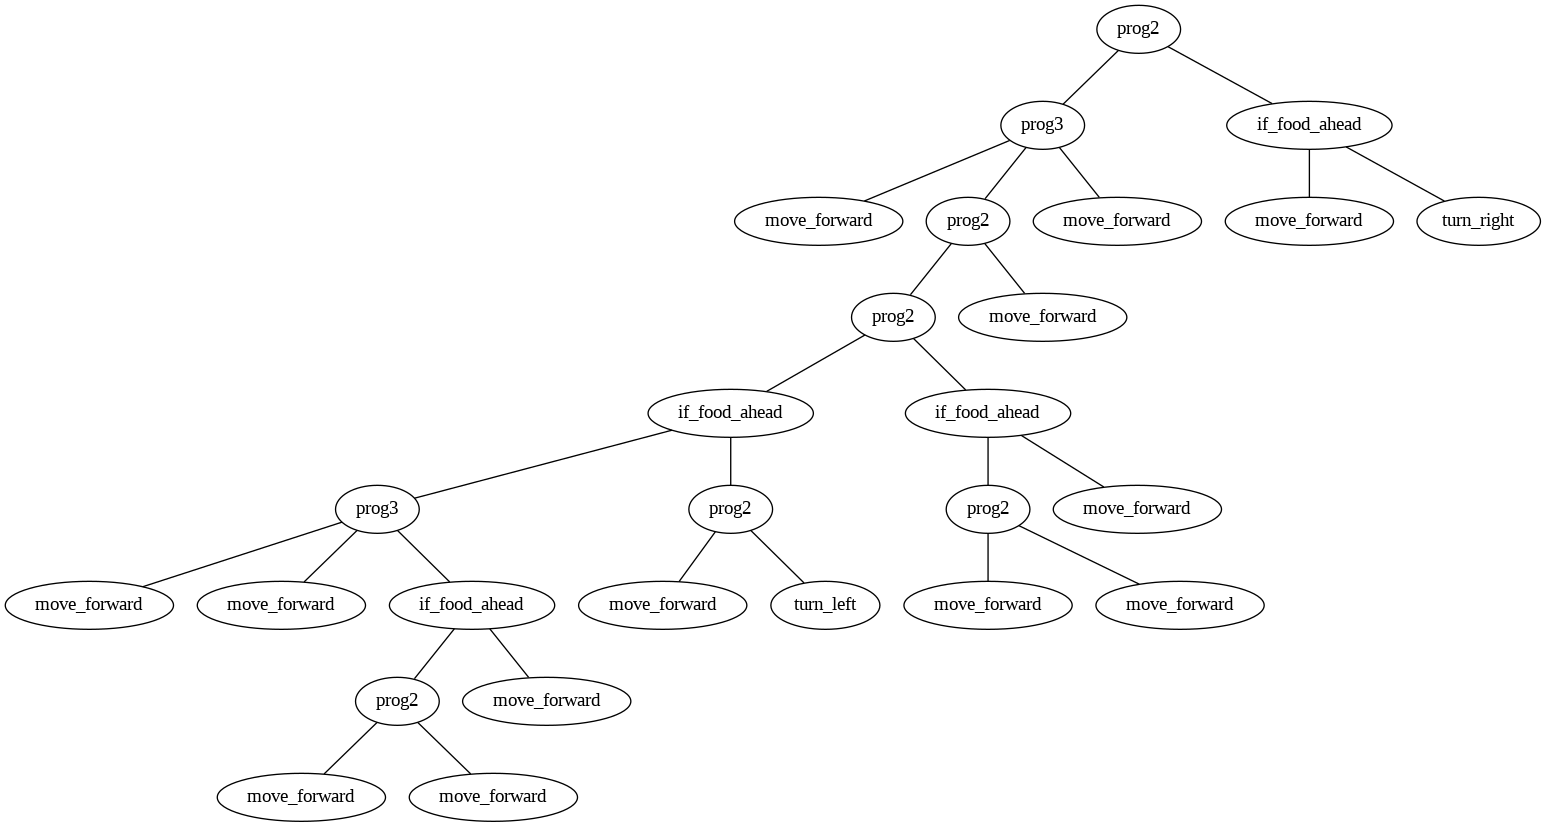

In [18]:
from IPython.display import Image

treePlot = tree.draw(format='png', prog='dot')  #create the image of the tree
Image(treePlot)                                 #display the image